## How do daily screen time affect sleep quality and stress levels of indivisuals, and can these be predicted using regression models?

## Introduction
- The dataset sleep_mobile_stress_dataset_15000.csv provides a comprehensive look into the intersection of digital habits and personal well-being. It tracks 15,000 individuals across various occupations to analyze how variables like daily screen time correlate with sleep quality and stress levels. As mobile connectivity becomes a constant in modern life, this data serves as a vital tool for identifying the physiological and psychological costs of high device engagement.

- **Inorder to study this ccorrelation I used  Random Forest regression model over Linear Regression because of the following reasons**.


- Capturing Non-Linearity: Human behavior rarely follows a perfectly straight line. For example, the impact of the first two hours of screen time on stress may be negligible, but the impact of the 8th or 9th hour might be exponential. Random Forest can capture these "threshold" effects that Linear Regression misses.

- Feature Interactions: Random Forest excels at understanding how features work together. It can identify if high caffeine intake only significantly degrades sleep quality when combined with high screen time, whereas Linear Regression often treats these factors in isolation unless complex interaction terms are manually added.

- Handling Categorical Diversity: With 15,000 entries and multiple occupations (e.g., Researcher, Manager, Teacher), the dataset contains diverse sub-groups. Random Forest naturally segments these groups through its tree-based structure, often leading to more accurate predictions across different lifestyles.

- Outlier Robustness: Behavioral data often includes outliers (e.g., a "power user" with extreme screen time but low stress). Random Forest is less sensitive to these anomalies compared to Linear Regression, which tries to fit a line that accounts for every single point, potentially skewing the results.

## Importing the necessary liberary 

In [4]:
import pandas as pd   #Data Handling
import numpy as np    #For numerical computation
import matplotlib.pyplot as plt #for plotting
import seaborn as sns #making plots more attractive and easier to read
from sklearn.model_selection import train_test_split  #Splitting the data
from sklearn.linear_model import LinearRegression     #Model the relatonship between Feature and target
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score  #Evaluation metrics

## Data Source: the source of this dataset is from [Kaggle](https://www.kaggle.com/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis)

### Load the data 

In [5]:
df = pd.read_csv("/home/abosent/Documents/sleep_mobile_stress_dataset_15000.csv")
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


### Data Exploring

In [6]:
df.info() #explore data type and missing value

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  str    
 3   occupation                        15000 non-null  str    
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  mental_fatigue_

In [9]:
df.describe() #statistical summary(mean, median std,etc...)

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


### Data Cleaning: - 
- Making data clean, consistent,and usable before applying the models.

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

### Correlation Heatmap
- shows correlations using colors instead of just numbers.

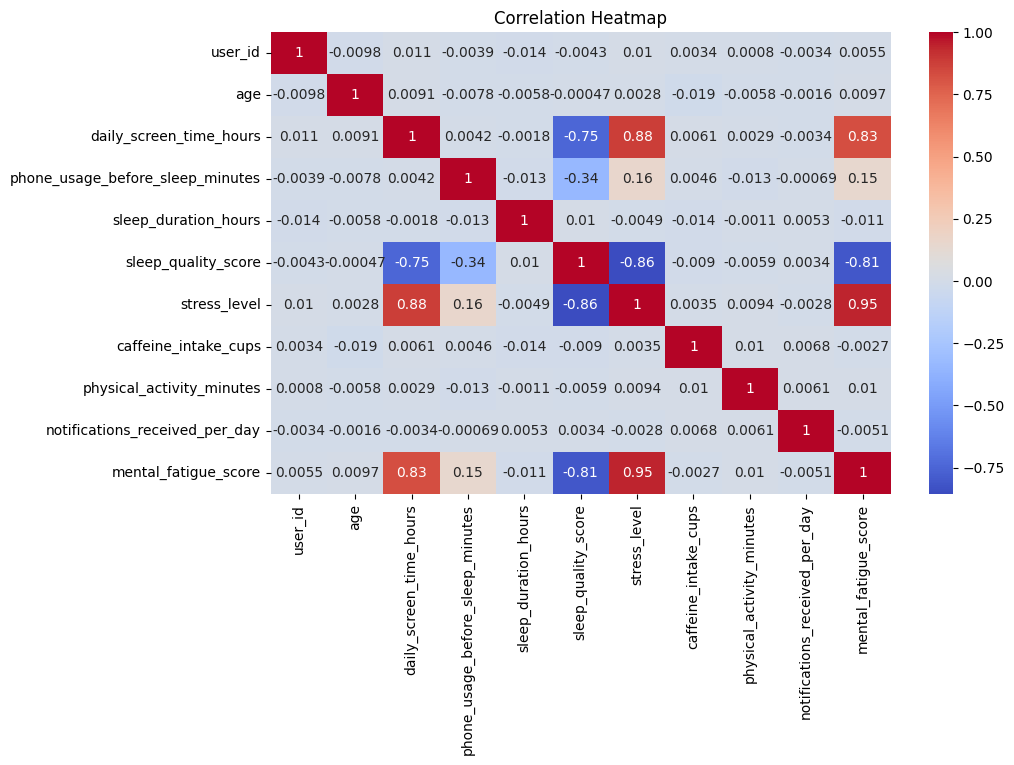

In [15]:
#visualize it using a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm') 

plt.title("Correlation Heatmap")
plt.show()

### From this correlation heatmap we have Key insights:

- Screen time vs sleep → negative
- Screen time vs stress → positive

## Relationships with Visualization:

- **Screen Time vs Sleep Quality**

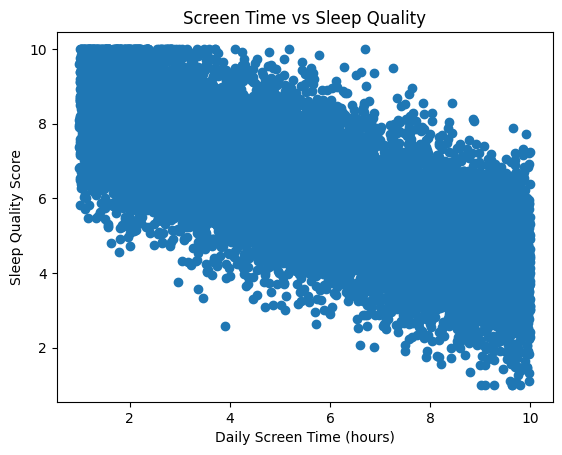

In [16]:
plt.figure()
plt.scatter(df['daily_screen_time_hours'], df['sleep_quality_score'])
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Sleep Quality Score")
plt.title("Screen Time vs Sleep Quality")
plt.show()

### Screen Time vs Stress Level

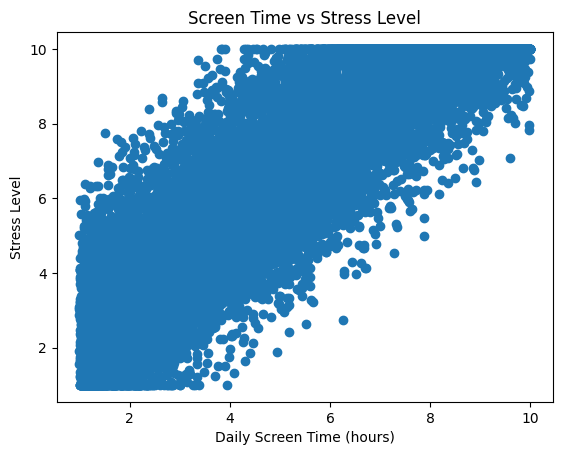

In [17]:
plt.figure()
plt.scatter(df['daily_screen_time_hours'], df['stress_level'])
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Stress Level")
plt.title("Screen Time vs Stress Level")
plt.show()

## Select Features X and Targets y & split data

In [22]:
X = df[[
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'notifications_received_per_day',
    'physical_activity_minutes',
    'caffeine_intake_cups'
]]

y = df[['sleep_quality_score', 'stress_level']]

#Spliting the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#80% training and 20% testing
#split the data in to train(learning from the data) and test(check the models performance)

# Linear regression

In [23]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [24]:
print("Linear Regression Results")

print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MSE: 1.2310122348475867
R2 Score: 0.7383982423365177


In [39]:
lr_results = pd.DataFrame({
    'Actual_Sleep': y_test['sleep_quality_score'].values,
    'Predicted_Sleep': y_pred_lr[:, 0],
    'Actual_Stress': y_test['stress_level'].values,
    'Predicted_Stress': y_pred_lr[:, 1]
})

lr_results.head()

,Actual_Sleep,Predicted_Sleep,Actual_Stress,Predicted_Stress
0,8.18,7.311799,4.74,5.609593
1,6.94,7.262912,6.94,4.978915
2,4.11,4.169165,10.00,10.426091
3,6.90,6.646470,4.29,5.211994
4,3.74,3.358609,10.00,11.430574


# Random Forest Regressor

In [25]:
rf_model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100))
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [26]:
print("Random Forest Results")

print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results
MSE: 1.2428109603283333
R2 Score: 0.7278226687490135


## Actual vs Predicted (Sleep quality and Stress)

In [32]:
rf_results = pd.DataFrame({
    'Actual_Sleep': y_test['sleep_quality_score'].values,
    'Predicted_Sleep': y_pred_rf[:, 0],
    'Actual_Stress': y_test['stress_level'].values,
    'Predicted_Stress': y_pred_rf[:, 1]
})

rf_results.head()

,Actual_Sleep,Predicted_Sleep,Actual_Stress,Predicted_Stress
0,8.18,7.2239,4.74,5.9197
1,6.94,7.4366,6.94,5.2562
2,4.11,3.8397,10.00,9.9309
3,6.90,6.8727,4.29,4.5117
4,3.74,3.9212,10.00,9.8394


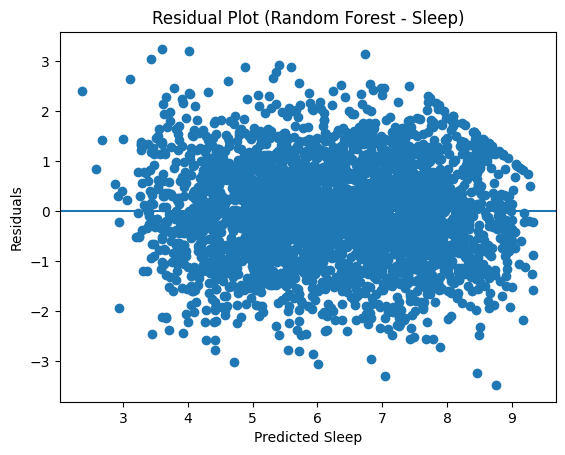

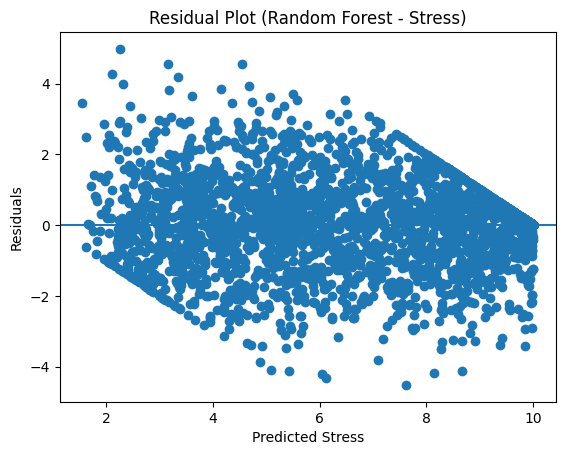

In [38]:
# Residuals for Sleep
residuals_sleep = y_test['sleep_quality_score'] - y_pred_rf[:, 0]

plt.figure()
plt.scatter(y_pred_rf[:, 0], residuals_sleep)

plt.xlabel("Predicted Sleep")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest - Sleep)")

plt.axhline(y=0)

plt.show()

# Residuals for Stress
residuals_stress = y_test['stress_level'] - y_pred_rf[:, 1]

plt.figure()
plt.scatter(y_pred_rf[:, 1], residuals_stress)

plt.xlabel("Predicted Stress")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest - Stress)")

plt.axhline(y=0)

plt.show()


## Plot Actual vs Predicted(Sleep_Quality)

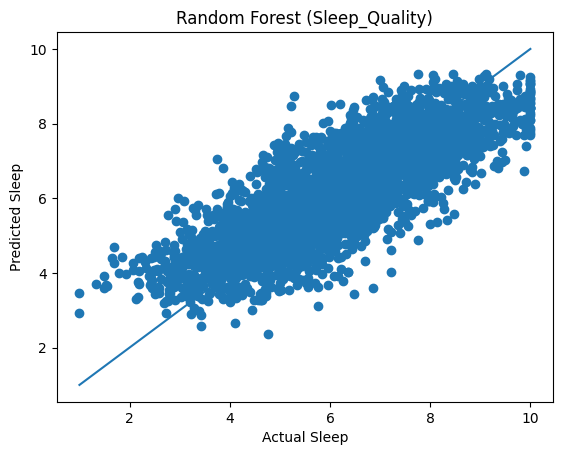

In [34]:
plt.figure()
plt.scatter(y_test['sleep_quality_score'], y_pred_rf[:,0])

plt.xlabel("Actual Sleep")
plt.ylabel("Predicted Sleep")
plt.title("Random Forest (Sleep_Quality)")

plt.plot([y_test['sleep_quality_score'].min(), y_test['sleep_quality_score'].max()],
         [y_test['sleep_quality_score'].min(), y_test['sleep_quality_score'].max()])

plt.show()

## Plot Actual vs Predicted(Stress)

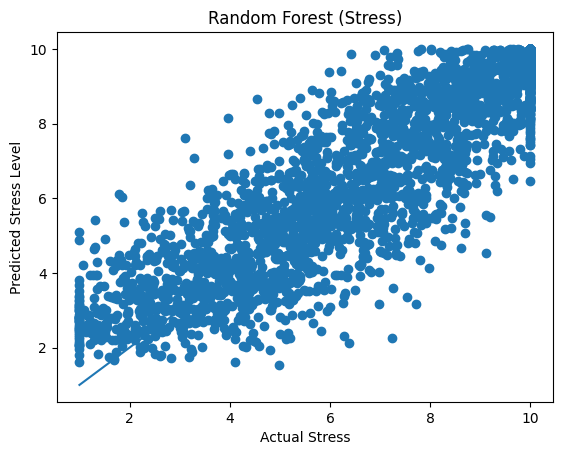

In [36]:
plt.figure()
plt.scatter(y_test['stress_level'], y_pred_rf[:,1])

plt.xlabel("Actual Stress")
plt.ylabel("Predicted Stress Level")
plt.title("Random Forest (Stress)")

plt.plot([y_test['stress_level'].min(), y_test['stress_level'].max()],
         [y_test['stress_level'].min(), y_test['stress_level'].max()])

plt.show()


## Feature Importance

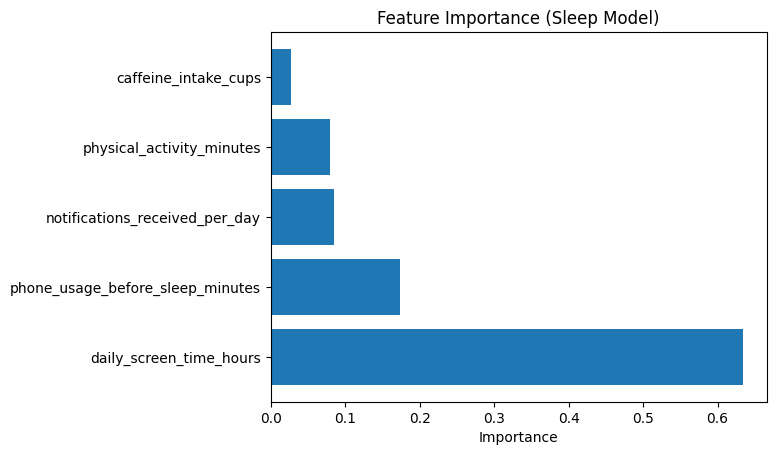

In [30]:
model = rf_model.estimators_[0]  # first model (sleep)

importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Sleep Model)")
plt.show()

- Daily Screen Time has high importance while Caffeine has less indicates that digital habits are a more powerful predictor of stress and sleep quality than chemical stimulants.

- Predictability: Sleep quality and stress levels can be predicted with high accuracy using regression models, provided the models account for non-linear behavioral patterns and feature interactions.  

- Non-Linear Impact: The relationship is not a simple straight line; the data suggests that high device engagement carries distinct physiological and psychological costs that become more severe as usage increases.  

- Interacting Factors: Digital habits do not act in isolation. The model highlights that factors like caffeine intake and physical activity interact with screen time to influence overall sleep quality.  

- Occupational Diversity: The study confirms that the impact of screen time varies across different lifestyles (e.g., Researchers vs. Managers), requiring the segmented approach offered by tree-based models to achieve reliable predictions.

## Limitation

- Fixed Range: Random Forest cannot predict stress or sleep scores outside the dataset's specific limits.

- No Causality: High screen time correlates with stress but doesn't prove it is the cause.

- Imbalanced Features: Rare habits (like zero caffeine) provide less data for the model to learn.

- Demographic Gap: Findings from these 15,000 subjects may not apply to children or the elderly.

- Sampling Bias: The 15,000 individuals may not perfectly represent the global population, leading to a Generalization Error